# Gurgaon Real Estate — Exploratory Data Analysis

An end-to-end EDA of ~3,800 residential property listings (flats and independent houses) in Gurgaon, India.

**Goals**

1. Audit data quality: duplicates, missing values, and data-entry errors.
2. Clean the dataset with a documented, reproducible pipeline (`src/cleaning.py`).
3. Understand what drives listing prices: property type, size, location, floor, furnishing, and amenities.

**Dataset** — `data/raw/gurgaon_properties.csv` (23 columns). Prices are in ₹ crore (1 crore = 10 million); `price_per_sqft` is in ₹; areas are in sq. ft. See `data/DATA_DICTIONARY.md` for the full column reference.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))  # make `src` importable when run from notebooks/

from src import cleaning
from src.config import RAW_DATA_PATH, PROCESSED_DATA_PATH, PALETTE, SERIES, BLUES, apply_plot_style, save_figure

apply_plot_style()
pd.set_option("display.max_columns", 30)
RANDOM_SEED = 42

## 1. First look at the raw data

In [2]:
raw = cleaning.load_raw(RAW_DATA_PATH)
print(f"{raw.shape[0]:,} listings x {raw.shape[1]} columns")
raw.head()

3,803 listings x 23 columns


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


In [3]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,3785.0,2.51,2.95,0.07,0.94,1.5,2.70,31.5
price_per_sqft,3785.0,13800.17,23052.01,4.00,6808.00,9000.0,13765.00,600000.0
area,3785.0,2846.00,22783.35,50.00,1220.00,1725.0,2295.00,875000.0
bedRoom,3803.0,3.34,1.88,1.00,2.00,3.0,4.00,21.0
bathroom,3803.0,3.41,1.93,1.00,2.00,3.0,4.00,21.0
floorNum,3784.0,6.81,6.03,0.00,2.00,5.0,10.00,51.0
super_built_up_area,1915.0,1921.66,767.16,89.00,1457.00,1828.0,2215.00,10000.0
built_up_area,1733.0,2360.24,17719.60,2.00,1100.00,1650.0,2399.00,737147.0
carpet_area,1944.0,2483.47,22375.24,15.00,824.00,1294.0,1786.25,607936.0
study room,3803.0,0.19,0.39,0.00,0.00,0.0,0.00,1.0


## 2. Data-quality audit

Before analysing anything, we check what is wrong with the raw feed:

- **Duplicates** — scraped listing feeds often repeat entries.
- **Missing values** — some fields (area breakdowns, facing) are optional on listing portals.
- **Implausible values** — unit mix-ups produce absurd areas and prices per sq. ft.

Exact duplicate rows: 126


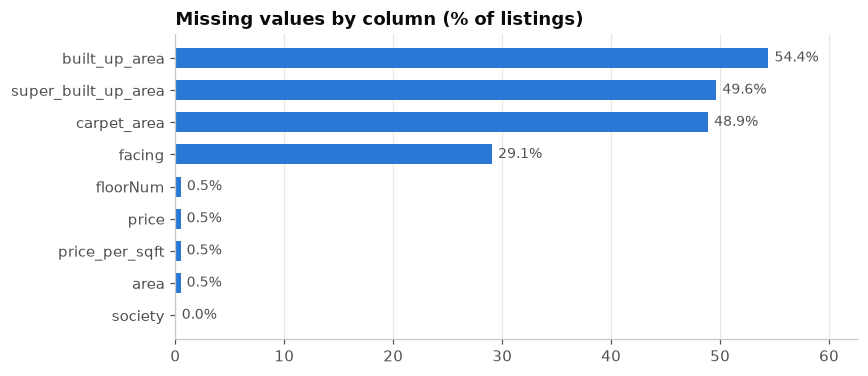

In [4]:
n_dupes = raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes}")

missing = (raw.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh(missing.index[::-1], missing.values[::-1], color=PALETTE["blue"], height=0.62)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color="#52514e")
ax.set_title("Missing values by column (% of listings)")
ax.set_xlim(0, missing.max() * 1.15)
ax.grid(axis="y", visible=False)
save_figure(fig, "missing_values")
plt.show()

Half the listings do not report a detailed area breakdown (`super_built_up_area`, `built_up_area`, `carpet_area`) and ~29% omit `facing` — that is how the source portal works, not a defect we can repair. We keep those columns as optional attributes and rely on the always-present `area` field for size analysis.

The extremes are clearly data-entry errors, not luxury properties: the raw maxima are an 875,000 sq. ft. "flat" and ₹600,000 per sq. ft. (roughly 60× the most expensive real market rate in Gurgaon).

In [5]:
raw_named = cleaning.standardize_columns(raw)
suspicious = raw_named[["property_type", "sector", "price", "price_per_sqft", "area", "bedrooms"]]
suspicious.nlargest(5, "area")

,property_type,sector,price,price_per_sqft,area,bedrooms
1648,flat,sohna road,0.35,4.0,875000.0,2
2111,flat,sector 95,0.45,7.0,642857.0,2
2651,flat,sector 95,0.31,5.0,620000.0,2
1638,flat,sector 107,0.51,9.0,566667.0,2
3021,house,sector 50,5.00,232.0,215517.0,6


## 3. Cleaning pipeline

The rules live in [`src/cleaning.py`](../src/cleaning.py) so they are reusable and testable outside the notebook:

1. Standardise column names to snake_case.
2. Drop exact duplicate listings.
3. Label categorical codes (`furnishing_type` 0/1/2 → names) and treat `age_possession = "Undefined"` as missing.
4. Drop the handful of listings with no price at all.
5. Trim listings outside the 0.5th–99.5th percentiles of `price_per_sqft` and `area` (unit errors, whole-building entries).

In [6]:
df, log = cleaning.clean_raw_data(raw)
for line in log:
    print(" -", line)
print(f"\nCleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

 - standardize column names: ok
 - drop exact duplicate listings: 126 rows removed (3677 remain)
 - label categorical columns: ok
 - drop listings without a price: 17 rows removed (3660 remain)
 - trim percentile outliers (price_per_sqft, area): 60 rows removed (3600 remain)

Cleaned dataset: 3,600 rows x 23 columns


## 4. Univariate analysis — what is on the market?

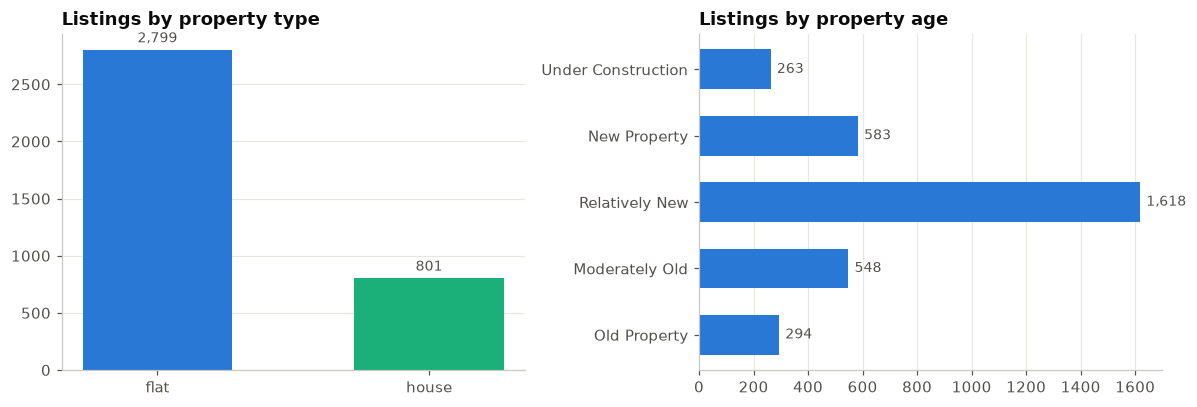

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

counts = df["property_type"].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=[PALETTE["blue"], PALETTE["aqua"]], width=0.55)
axes[0].bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9, color="#52514e")
axes[0].set_title("Listings by property type")
axes[0].grid(axis="x", visible=False)

order = ["Under Construction", "New Property", "Relatively New", "Moderately Old", "Old Property"]
age = df["age_possession"].value_counts().reindex(order)
bars = axes[1].barh(age.index[::-1], age.values[::-1], color=PALETTE["blue"], height=0.6)
axes[1].bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9, color="#52514e")
axes[1].set_title("Listings by property age")
axes[1].grid(axis="y", visible=False)

fig.tight_layout()
save_figure(fig, "market_composition")
plt.show()

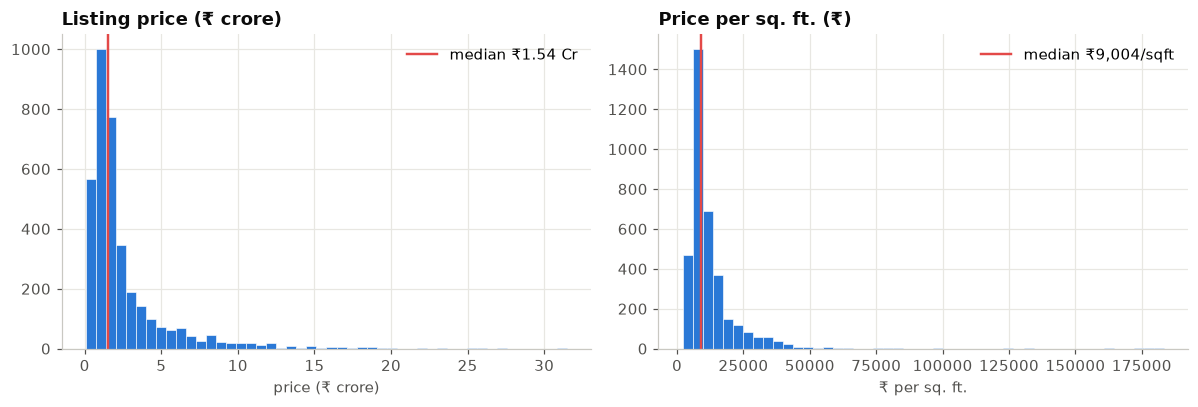

Price skewness: 3.31 — long right tail, so we report medians rather than means.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df["price"], bins=48, color=PALETTE["blue"], edgecolor="white", linewidth=0.4)
axes[0].axvline(df["price"].median(), color=PALETTE["red"], linewidth=1.6,
                label=f"median ₹{df['price'].median():.2f} Cr")
axes[0].set_title("Listing price (₹ crore)")
axes[0].set_xlabel("price (₹ crore)")
axes[0].legend()

axes[1].hist(df["price_per_sqft"], bins=48, color=PALETTE["blue"], edgecolor="white", linewidth=0.4)
axes[1].axvline(df["price_per_sqft"].median(), color=PALETTE["red"], linewidth=1.6,
                label=f"median ₹{df['price_per_sqft'].median():,.0f}/sqft")
axes[1].set_title("Price per sq. ft. (₹)")
axes[1].set_xlabel("₹ per sq. ft.")
axes[1].legend()

fig.tight_layout()
save_figure(fig, "price_distributions")
plt.show()

print(f"Price skewness: {df['price'].skew():.2f} — long right tail, so we report medians rather than means.")

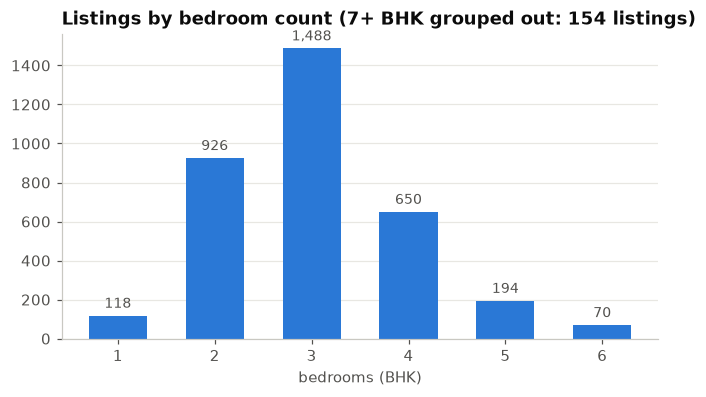

In [9]:
counts = df["bedrooms"].value_counts().sort_index()
counts_small = counts[counts.index <= 6]

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(counts_small.index.astype(str), counts_small.values, color=PALETTE["blue"], width=0.6)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9, color="#52514e")
ax.set_title("Listings by bedroom count (7+ BHK grouped out: "
             f"{counts[counts.index > 6].sum()} listings)")
ax.set_xlabel("bedrooms (BHK)")
ax.grid(axis="x", visible=False)
save_figure(fig, "bedroom_counts")
plt.show()

The market is dominated by 2–4 BHK flats. 3 BHK is the single largest segment — the default family configuration in Gurgaon's high-rise societies.

## 5. What drives price?

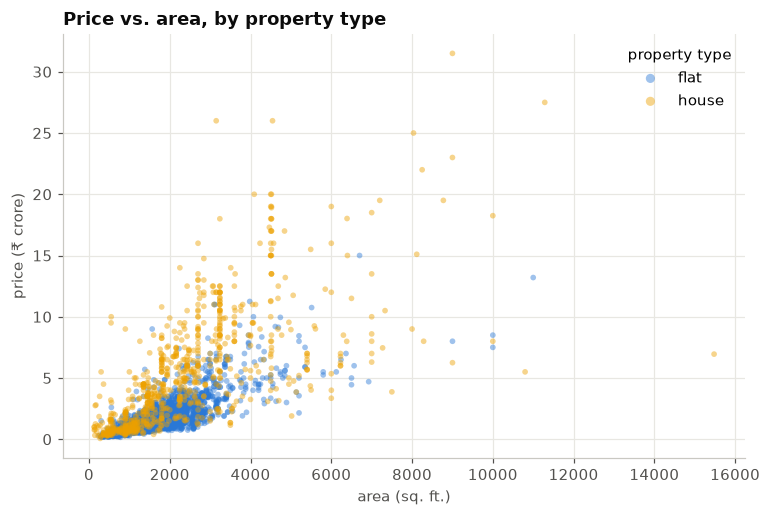

flat : corr(area, price) = 0.78, median ₹1.39 Cr, median ₹8,367/sqft
house: corr(area, price) = 0.67, median ₹4.25 Cr, median ₹20,000/sqft


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for ptype, color in [("flat", PALETTE["blue"]), ("house", PALETTE["yellow"])]:
    sub = df[df["property_type"] == ptype]
    ax.scatter(sub["area"], sub["price"], s=14, alpha=0.45, color=color, label=ptype, edgecolors="none")
ax.set_title("Price vs. area, by property type")
ax.set_xlabel("area (sq. ft.)")
ax.set_ylabel("price (₹ crore)")
ax.legend(title="property type", markerscale=1.6)
save_figure(fig, "price_vs_area")
plt.show()

for ptype in ["flat", "house"]:
    sub = df[df["property_type"] == ptype]
    r = np.corrcoef(sub["area"], sub["price"])[0, 1]
    print(f"{ptype:5s}: corr(area, price) = {r:.2f}, median ₹{sub['price'].median():.2f} Cr, "
          f"median ₹{sub['price_per_sqft'].median():,.0f}/sqft")

Houses command roughly triple the median price of flats and sit on much larger plots — two distinct markets sharing one city.

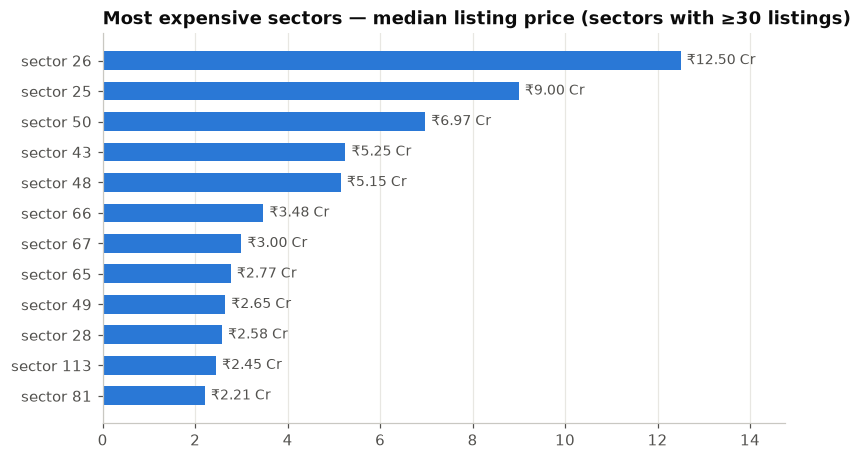

In [11]:
sector_stats = (df.groupby("sector")
                  .agg(median_price=("price", "median"), listings=("price", "size"))
                  .query("listings >= 30")
                  .sort_values("median_price", ascending=False))

top = sector_stats.head(12)
fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.barh(top.index[::-1], top["median_price"][::-1], color=PALETTE["blue"], height=0.62)
ax.bar_label(bars, fmt="₹%.2f Cr", padding=4, fontsize=9, color="#52514e")
ax.set_title("Most expensive sectors — median listing price (sectors with ≥30 listings)")
ax.set_xlim(0, top["median_price"].max() * 1.18)
ax.grid(axis="y", visible=False)
save_figure(fig, "top_sectors_by_price")
plt.show()

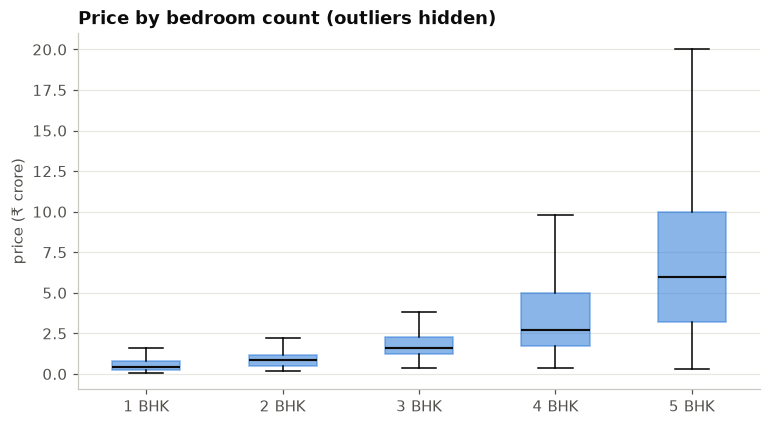

In [12]:
seg = df[df["bedrooms"].between(1, 5)]
fig, ax = plt.subplots(figsize=(8, 4.2))
data = [seg.loc[seg["bedrooms"] == b, "price"].values for b in range(1, 6)]
bp = ax.boxplot(data, tick_labels=[f"{b} BHK" for b in range(1, 6)], showfliers=False,
                patch_artist=True, medianprops={"color": "#0b0b0b", "linewidth": 1.4})
for patch in bp["boxes"]:
    patch.set(facecolor=PALETTE["blue"], alpha=0.55, edgecolor=PALETTE["blue"])
ax.set_title("Price by bedroom count (outliers hidden)")
ax.set_ylabel("price (₹ crore)")
ax.grid(axis="x", visible=False)
save_figure(fig, "price_by_bedrooms")
plt.show()

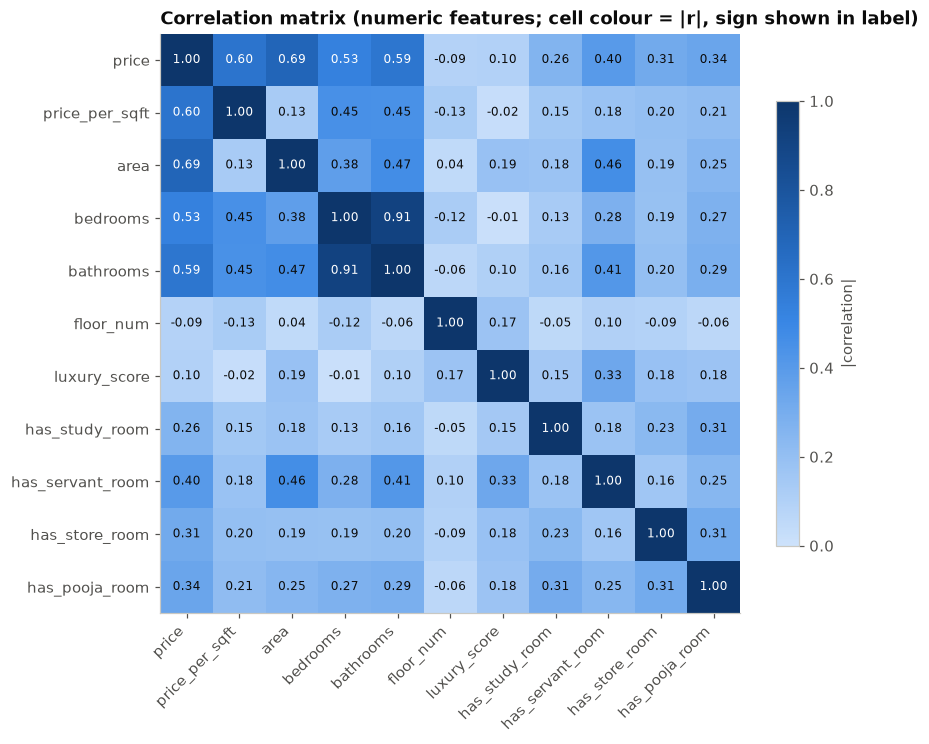

In [13]:
num_cols = ["price", "price_per_sqft", "area", "bedrooms", "bathrooms",
            "floor_num", "luxury_score",
            "has_study_room", "has_servant_room", "has_store_room", "has_pooja_room"]
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr.abs(), cmap=BLUES, vmin=0, vmax=1)
ax.grid(False)
ax.set_xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.5 else "#0b0b0b")
ax.set_title("Correlation matrix (numeric features; cell colour = |r|, sign shown in label)")
fig.colorbar(im, ax=ax, shrink=0.75, label="|correlation|")
save_figure(fig, "correlation_matrix")
plt.show()

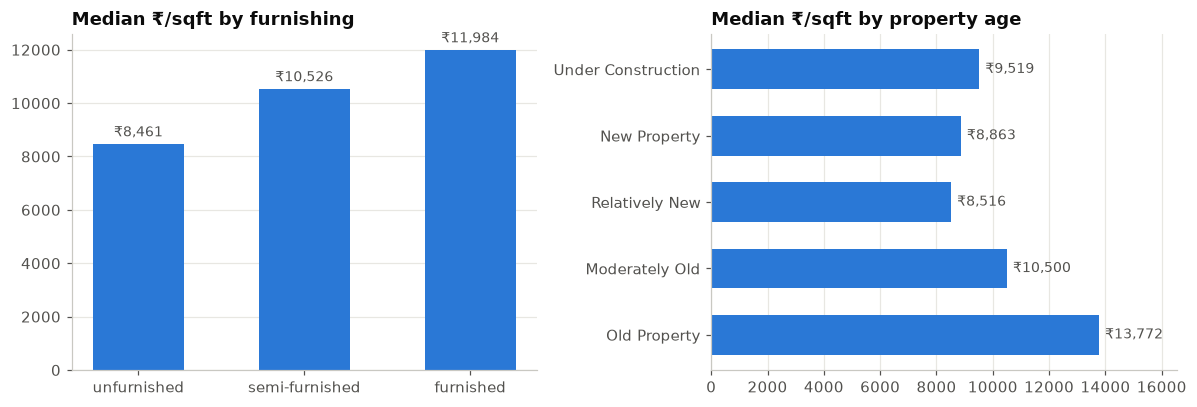

In [14]:
furn = (df.groupby("furnishing_type")["price_per_sqft"]
          .median()
          .reindex(["unfurnished", "semi-furnished", "furnished"]))
age_ppsf = (df.groupby("age_possession")["price_per_sqft"]
              .median()
              .reindex(["Under Construction", "New Property", "Relatively New",
                        "Moderately Old", "Old Property"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bars = axes[0].bar(furn.index, furn.values, color=PALETTE["blue"], width=0.55)
axes[0].bar_label(bars, fmt="₹{:,.0f}", padding=3, fontsize=9, color="#52514e")
axes[0].set_title("Median ₹/sqft by furnishing")
axes[0].grid(axis="x", visible=False)

bars = axes[1].barh(age_ppsf.index[::-1], age_ppsf.values[::-1], color=PALETTE["blue"], height=0.6)
axes[1].bar_label(bars, fmt="₹{:,.0f}", padding=4, fontsize=9, color="#52514e")
axes[1].set_title("Median ₹/sqft by property age")
axes[1].set_xlim(0, age_ppsf.max() * 1.2)
axes[1].grid(axis="y", visible=False)

fig.tight_layout()
save_figure(fig, "ppsf_by_furnishing_and_age")
plt.show()

## 6. Key findings

1. **Two markets, one city.** Independent houses have a median price ~3× that of flats and a materially higher ₹/sqft; size (`area`) is the strongest single price driver within each segment.
2. **Location is a step function.** Median prices across sectors with ≥30 listings span roughly 5×; Gurgaon's "golden corridor" sectors top the table, while peripheral sectors remain affordable.
3. **3 BHK is the market's centre of gravity**, and price scales steeply — each additional bedroom roughly doubles the median price up to 5 BHK.
4. **Bathrooms track bedrooms almost perfectly** (r ≈ 0.9); together with area they make the intuitive "size cluster" in the correlation matrix.
5. **Amenity rooms are luxury markers.** Servant/store/pooja rooms correlate with price mostly through property size and the `luxury_score`, not independently.
6. **New sells dear.** Under-construction and new properties command the highest median ₹/sqft — buyers pay a premium for modern stock despite possession risk.
7. **Data quality matters.** 126 duplicate rows and ~1% unit-error listings (e.g. an "875,000 sq. ft. flat") would have badly skewed means; medians plus percentile trimming keep the analysis honest.

## 7. Export the cleaned dataset

In [15]:
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Saved {len(df):,} rows -> {PROCESSED_DATA_PATH.relative_to(PROCESSED_DATA_PATH.parents[2])}")

Saved 3,600 rows -> data/processed/gurgaon_properties_cleaned.csv
